# drive mont

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**Week 1: Project Initialization and Dataset Acquisition.**


# **DATA**  & Explore the structure and quality of each datase


In [4]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt




In [5]:
import pandas as pd

path = '/content/drive/MyDrive/Ridewise-data/'

hour_df = pd.read_csv(path + 'hour.csv')
day_df = pd.read_csv(path + 'day.csv')


In [6]:
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [7]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [8]:
print("Hour dataset shape:", hour_df.shape)
print("Day dataset shape:", day_df.shape)

Hour dataset shape: (17379, 17)
Day dataset shape: (731, 16)


In [9]:
print("===== MISSING VALUES: HOUR DATA =====")
print(hour_df.isnull().sum())

print("\n===== MISSING VALUES: DAY DATA =====")
print(day_df.isnull().sum())

===== MISSING VALUES: HOUR DATA =====
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

===== MISSING VALUES: DAY DATA =====
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [10]:
print("===== DATA TYPES: HOUR DATA =====")
print(hour_df.dtypes)

print("\n===== DATA TYPES: DAY DATA =====")
print(day_df.dtypes)


===== DATA TYPES: HOUR DATA =====
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

===== DATA TYPES: DAY DATA =====
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


In [11]:
print("\n===== COLUMNS: HOUR DATA =====")
print(hour_df.columns)

print("\n===== COLUMNS: DAY DATA =====")
print(day_df.columns)


===== COLUMNS: HOUR DATA =====
Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

===== COLUMNS: DAY DATA =====
Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')


# **week2 Data Preprocessing and Feature Selection**

**Data Cleaning and Preprocessing of Hourly Bike-Sharing Dataset**

In [12]:
import pandas as pd
import numpy as np
path = "/content/drive/MyDrive/Ridewise-data/"
df = pd.read_csv(path + "hour.csv")
df.drop(["instant", "casual", "registered"], axis=1, inplace=True)  # Removing rhe leakage & irrelevant columns.
df["dteday"] = pd.to_datetime(df["dteday"])
df.drop_duplicates(inplace=True) #Remove duplicates
cat_cols = ["season", "yr", "mnth", "hr", "holiday", "weekday", "workingday", "weathersit"]
df[cat_cols] = df[cat_cols].astype(int)
df = df.ffill()


#  TIME FEATURES
df["year"] = df["yr"]
df["month"] = df["dteday"].dt.month
df["day"] = df["dteday"].dt.day
df["weekday"] = df["dteday"].dt.weekday
df["is_weekend"] = df["weekday"].isin([5, 6]).astype(int)
df["week_of_year"] = df["dteday"].dt.isocalendar().week.astype(int)

# CYCLIC
df["hour_sin"] = np.sin(2 * np.pi * df["hr"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hr"] / 24)

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

#WEATHER FEATURES
df["temp_level"] = pd.cut(
    df["temp"],
    bins=[0, 0.33, 0.66, 1],
    labels=["Low", "Medium", "High"]
)

df["humid_flag"] = (df["hum"] > df["hum"].mean()).astype(int)
df["windy_flag"] = (df["windspeed"] > df["windspeed"].mean()).astype(int)

df["weather_severity"] = (
    (df["temp"] * 0.4) +
    (df["hum"] * 0.3) +
    (df["windspeed"] * 0.3)
)

df["storm_flag"] = (df["weathersit"] >= 3).astype(int)

#EVENT FEATURES
df["is_holiday"] = df["holiday"]
df["is_working_day"] = df["workingday"]
df["event_day"] = ((df["holiday"] == 1) | (df["workingday"] == 0)).astype(int)

#  LAG FEATURES
df["cnt_lag_1"] = df["cnt"].shift(1)
df["cnt_lag_24"] = df["cnt"].shift(24)

# Rolling average
df["cnt_rolling_24"] = df["cnt"].rolling(window=24).mean()

# Remove NaNs created by lag/rolling
df = df.dropna().reset_index(drop=True)

#  FINAL CLEANUP
df.drop(["dteday", "year"], axis=1, inplace=True)

print("Final dataset shape after preprocessing:", df.shape)
df.head()

print("------------------------------------------------------")
print("✔ Preprocessing Completed Successfully")
print("✔ No errors encountered")
print("✔ Final dataset shape:", df.shape)
print("✔ Columns:", len(df.columns))
print("------------------------------------------------------")

print("\n SAMPLE ROWS AFTER PREPROCESSING:")
display(df.head())

print("\n SUMMARY STATISTICS:")
display(df.describe())

print("\n NULL VALUES CHECK:")
print(df.isnull().sum())



Final dataset shape after preprocessing: (17355, 32)
------------------------------------------------------
✔ Preprocessing Completed Successfully
✔ No errors encountered
✔ Final dataset shape: (17355, 32)
✔ Columns: 32
------------------------------------------------------

 SAMPLE ROWS AFTER PREPROCESSING:


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,...,humid_flag,windy_flag,weather_severity,storm_flag,is_holiday,is_working_day,event_day,cnt_lag_1,cnt_lag_24,cnt_rolling_24
0,1,0,1,0,0,6,0,2,0.46,0.4545,...,1,1,0.53755,0,0,0,1,39.0,16.0,41.083333
1,1,0,1,1,0,6,0,2,0.44,0.4394,...,1,1,0.53411,0,0,0,1,17.0,40.0,40.125000
2,1,0,1,2,0,6,0,2,0.42,0.4242,...,1,1,0.55308,0,0,0,1,17.0,32.0,39.166667
3,1,0,1,3,0,6,0,2,0.46,0.4545,...,1,1,0.52420,0,0,0,1,9.0,13.0,38.875000
4,1,0,1,4,0,6,0,2,0.46,0.4545,...,1,1,0.52420,0,0,0,1,6.0,1.0,38.958333



 SUMMARY STATISTICS:


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,...,humid_flag,windy_flag,weather_severity,storm_flag,is_holiday,is_working_day,event_day,cnt_lag_1,cnt_lag_24,cnt_rolling_24
count,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,...,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000
mean,2.503717,0.503256,6.545434,11.546816,0.028810,3.008701,0.683665,1.425065,0.497199,0.475930,...,0.502103,0.501873,0.444016,0.081821,0.028810,0.683665,0.316335,189.667761,189.567848,189.611822
std,1.106273,0.500004,3.434976,6.914394,0.167277,2.001983,0.465059,0.639329,0.192573,0.171897,...,0.500010,0.500011,0.092981,0.274099,0.167277,0.465059,0.465059,181.425094,181.462851,78.941873
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,...,0.000000,0.000000,0.132000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,18.041667
25%,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,...,0.000000,0.000000,0.373040,0.000000,0.000000,0.000000,0.000000,40.000000,40.000000,133.250000
50%,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,...,1.000000,1.000000,0.454170,0.000000,0.000000,1.000000,0.000000,142.000000,142.000000,189.666667
75%,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,...,1.000000,1.000000,0.518880,0.000000,0.000000,1.000000,1.000000,281.000000,281.000000,248.395833
max,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,...,1.000000,1.000000,0.773740,1.000000,1.000000,1.000000,1.000000,977.000000,977.000000,382.500000



 NULL VALUES CHECK:
season              0
yr                  0
mnth                0
hr                  0
holiday             0
weekday             0
workingday          0
weathersit          0
temp                0
atemp               0
hum                 0
windspeed           0
cnt                 0
month               0
day                 0
is_weekend          0
week_of_year        0
hour_sin            0
hour_cos            0
month_sin           0
month_cos           0
temp_level          0
humid_flag          0
windy_flag          0
weather_severity    0
storm_flag          0
is_holiday          0
is_working_day      0
event_day           0
cnt_lag_1           0
cnt_lag_24          0
cnt_rolling_24      0
dtype: int64


# Correlation Heatmap Showing Relationships Between Weather, Time, and Demand Features



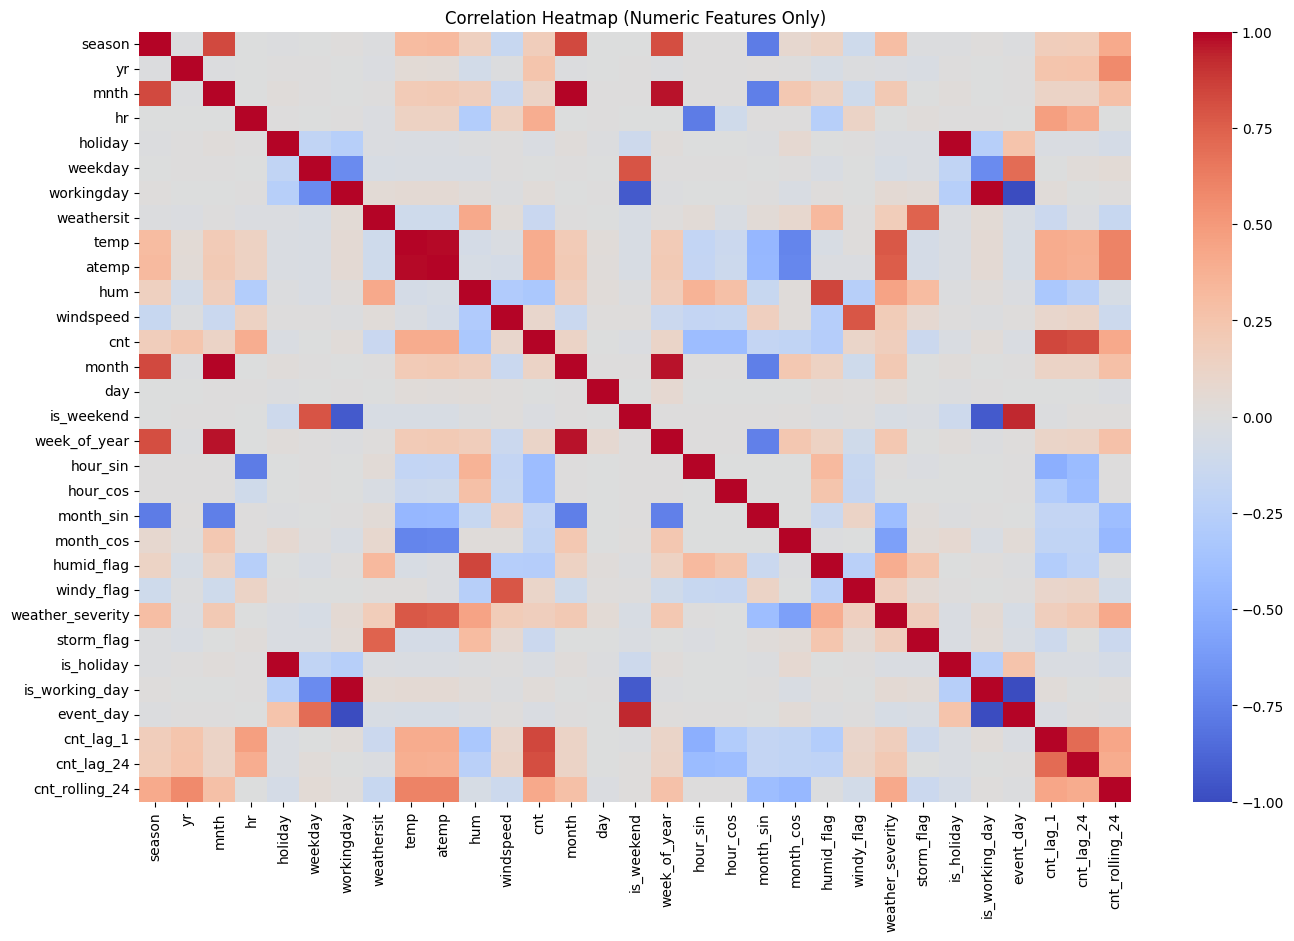

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(16, 10))
corr = numeric_df.corr()
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()



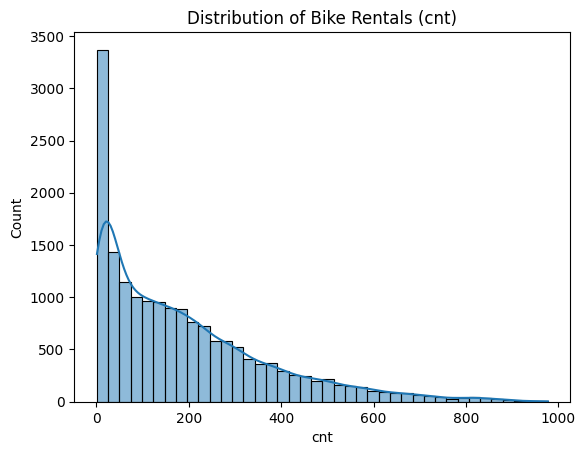

In [17]:
sns.histplot(df['cnt'], bins=40, kde=True)
plt.title("Distribution of Bike Rentals (cnt)")
plt.show()


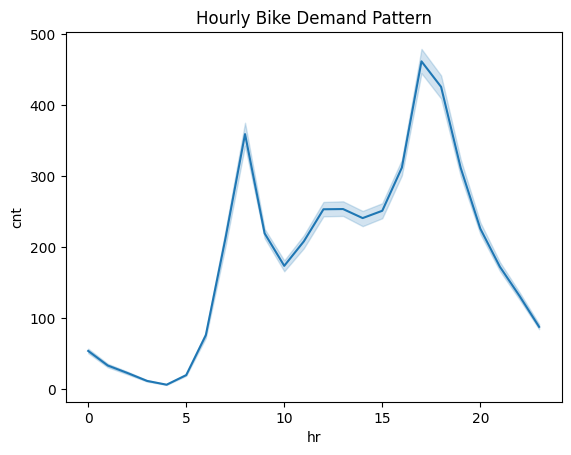

In [18]:
sns.lineplot(x="hr", y="cnt", data=df)
plt.title("Hourly Bike Demand Pattern")
plt.show()


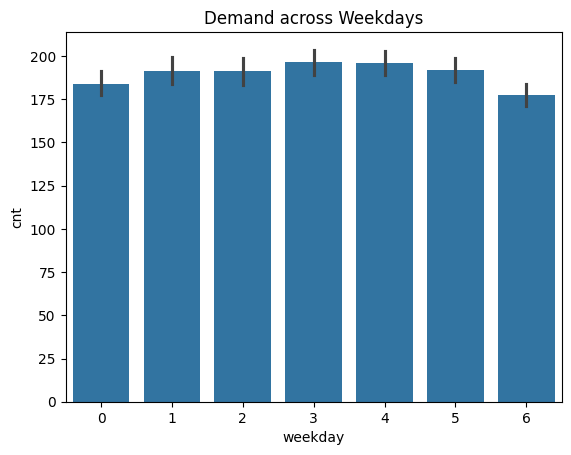

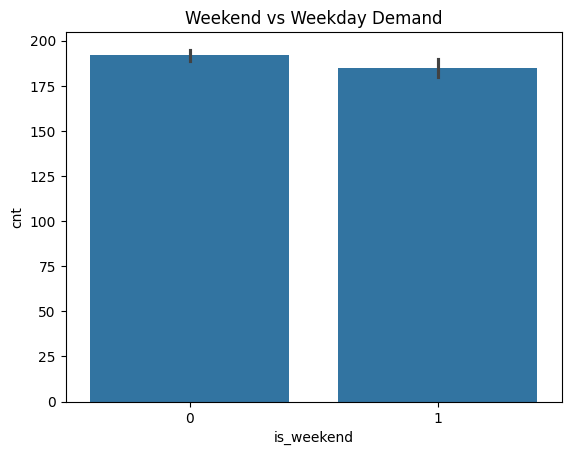

In [19]:
sns.barplot(x="weekday", y="cnt", data=df)
plt.title("Demand across Weekdays")
plt.show()

sns.barplot(x="is_weekend", y="cnt", data=df)
plt.title("Weekend vs Weekday Demand")
plt.show()


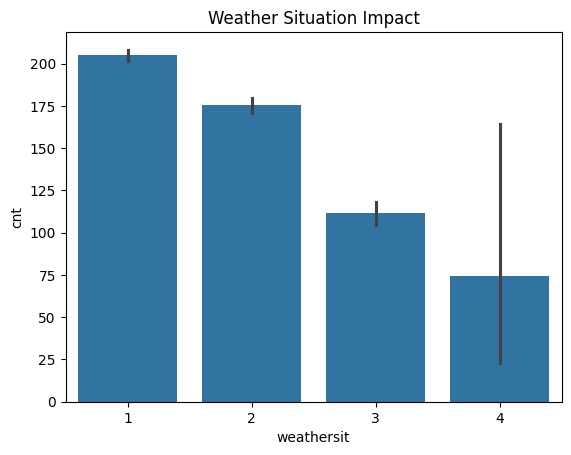

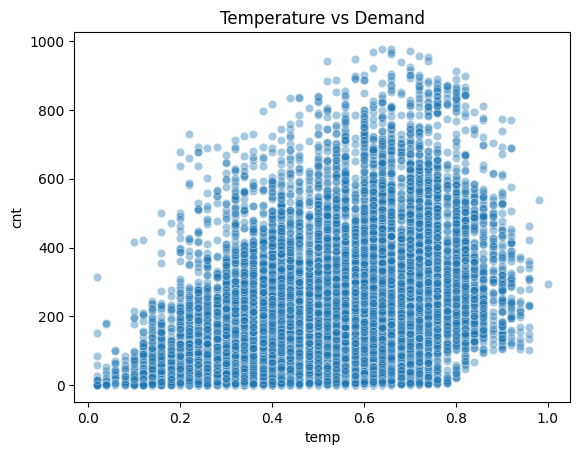

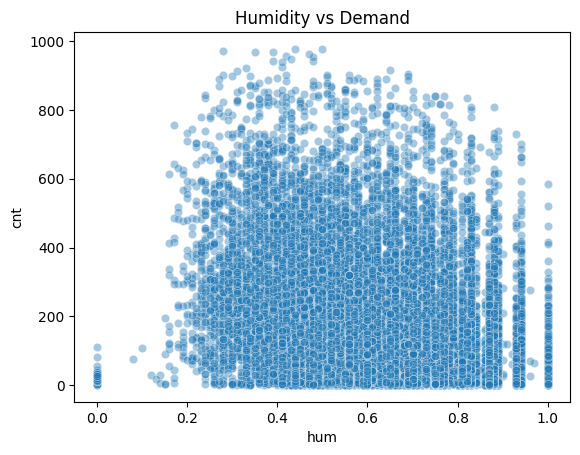

In [20]:
sns.barplot(x="weathersit", y="cnt", data=df)
plt.title("Weather Situation Impact")
plt.show()

sns.scatterplot(x="temp", y="cnt", alpha=0.4, data=df)
plt.title("Temperature vs Demand")
plt.show()

sns.scatterplot(x="hum", y="cnt", alpha=0.4, data=df)
plt.title("Humidity vs Demand")
plt.show()


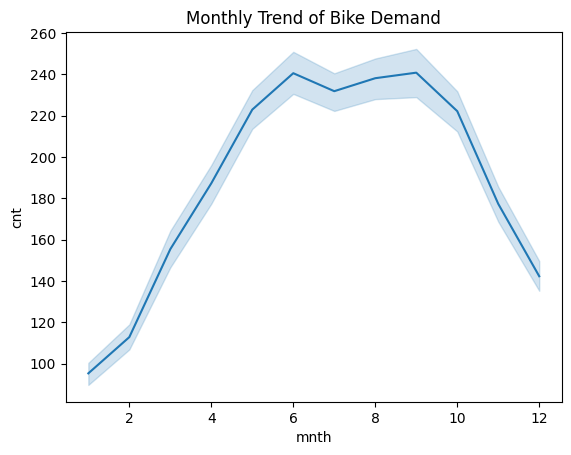

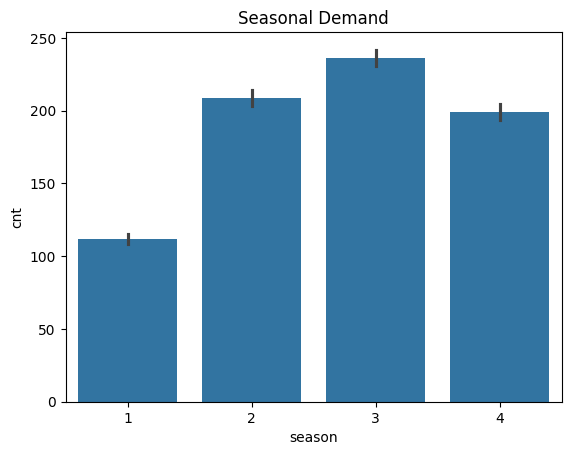

In [21]:
sns.lineplot(x="mnth", y="cnt", data=df)
plt.title("Monthly Trend of Bike Demand")
plt.show()

sns.barplot(x="season", y="cnt", data=df)
plt.title("Seasonal Demand")
plt.show()


In [22]:
drop_cols = ["instant", "dteday", "yr", "casual", "registered"]
existing_drop_cols = [col for col in drop_cols if col in df.columns]
df.drop(existing_drop_cols, axis=1, inplace=True)
print("-----------------------------------------------------")
print(" Columns dropped:", existing_drop_cols)
print(" Number of columns dropped:", len(existing_drop_cols))
print("-----------------------------------------------------")

print("\n Remaining Columns (After Dropping):")
print(list(df.columns))
print("\nTotal Remaining Columns:", len(df.columns))

print("\nFinal Dataset Shape:", df.shape)


-----------------------------------------------------
 Columns dropped: ['yr']
 Number of columns dropped: 1
-----------------------------------------------------

 Remaining Columns (After Dropping):
['season', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt', 'month', 'day', 'is_weekend', 'week_of_year', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'temp_level', 'humid_flag', 'windy_flag', 'weather_severity', 'storm_flag', 'is_holiday', 'is_working_day', 'event_day', 'cnt_lag_1', 'cnt_lag_24', 'cnt_rolling_24']

Total Remaining Columns: 31

Final Dataset Shape: (17355, 31)


In [ ]:
df.head()

,season,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,...,humid_flag,windy_flag,weather_severity,storm_flag,is_holiday,is_working_day,event_day,cnt_lag_1,cnt_lag_24,cnt_rolling_24
0,1,1,0,0,6,0,2,0.46,0.4545,0.88,...,1,1,0.53755,0,0,0,1,39.0,16.0,41.083333
1,1,1,1,0,6,0,2,0.44,0.4394,0.94,...,1,1,0.53411,0,0,0,1,17.0,40.0,40.125000
2,1,1,2,0,6,0,2,0.42,0.4242,1.00,...,1,1,0.55308,0,0,0,1,17.0,32.0,39.166667
3,1,1,3,0,6,0,2,0.46,0.4545,0.94,...,1,1,0.52420,0,0,0,1,9.0,13.0,38.875000
4,1,1,4,0,6,0,2,0.46,0.4545,0.94,...,1,1,0.52420,0,0,0,1,6.0,1.0,38.958333


# EDA -> Exploratory Data Analysis

In [23]:
print("===== DATASET SHAPE =====")
print(df.shape)

print("\n===== DATA TYPES =====")
print(df.dtypes)

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

print("\n===== SUMMARY STATISTICS =====")
display(df.describe())


===== DATASET SHAPE =====
(17355, 31)

===== DATA TYPES =====
season                 int64
mnth                   int64
hr                     int64
holiday                int64
weekday                int32
workingday             int64
weathersit             int64
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
cnt                    int64
month                  int32
day                    int32
is_weekend             int64
week_of_year           int64
hour_sin             float64
hour_cos             float64
month_sin            float64
month_cos            float64
temp_level          category
humid_flag             int64
windy_flag             int64
weather_severity     float64
storm_flag             int64
is_holiday             int64
is_working_day         int64
event_day              int64
cnt_lag_1            float64
cnt_lag_24           float64
cnt_rolling_24       float64
dtype: object

===== MISSING VALUES ===

,season,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,...,humid_flag,windy_flag,weather_severity,storm_flag,is_holiday,is_working_day,event_day,cnt_lag_1,cnt_lag_24,cnt_rolling_24
count,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,...,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000
mean,2.503717,6.545434,11.546816,0.028810,3.008701,0.683665,1.425065,0.497199,0.475930,0.626982,...,0.502103,0.501873,0.444016,0.081821,0.028810,0.683665,0.316335,189.667761,189.567848,189.611822
std,1.106273,3.434976,6.914394,0.167277,2.001983,0.465059,0.639329,0.192573,0.171897,0.192937,...,0.500010,0.500011,0.092981,0.274099,0.167277,0.465059,0.465059,181.425094,181.462851,78.941873
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,...,0.000000,0.000000,0.132000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,18.041667
25%,2.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,...,0.000000,0.000000,0.373040,0.000000,0.000000,0.000000,0.000000,40.000000,40.000000,133.250000
50%,3.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,...,1.000000,1.000000,0.454170,0.000000,0.000000,1.000000,0.000000,142.000000,142.000000,189.666667
75%,3.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,...,1.000000,1.000000,0.518880,0.000000,0.000000,1.000000,1.000000,281.000000,281.000000,248.395833
max,4.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,0.773740,1.000000,1.000000,1.000000,1.000000,977.000000,977.000000,382.500000


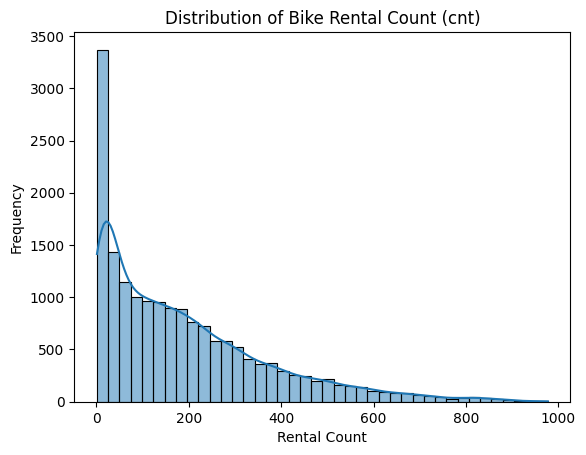

In [24]:
sns.histplot(df['cnt'], kde=True, bins=40)
plt.title("Distribution of Bike Rental Count (cnt)")
plt.xlabel("Rental Count")
plt.ylabel("Frequency")
plt.show()


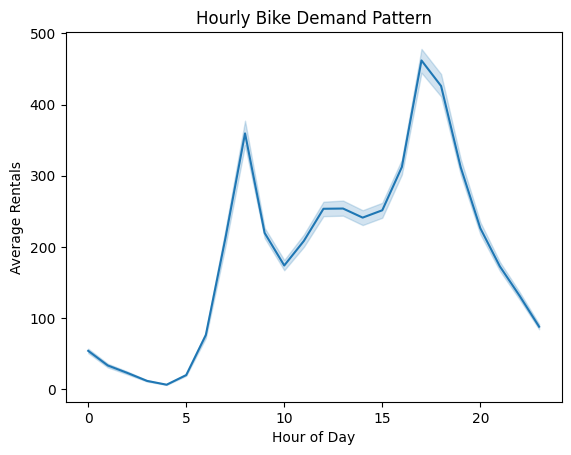

In [25]:
sns.lineplot(x='hr', y='cnt', data=df)
plt.title("Hourly Bike Demand Pattern")
plt.xlabel("Hour of Day")
plt.ylabel("Average Rentals")
plt.show()


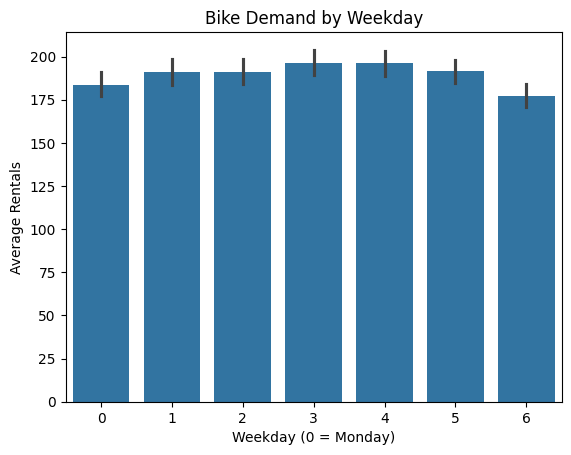

In [26]:
sns.barplot(x='weekday', y='cnt', data=df, estimator='mean')
plt.title("Bike Demand by Weekday")
plt.xlabel("Weekday (0 = Monday)")
plt.ylabel("Average Rentals")
plt.show()


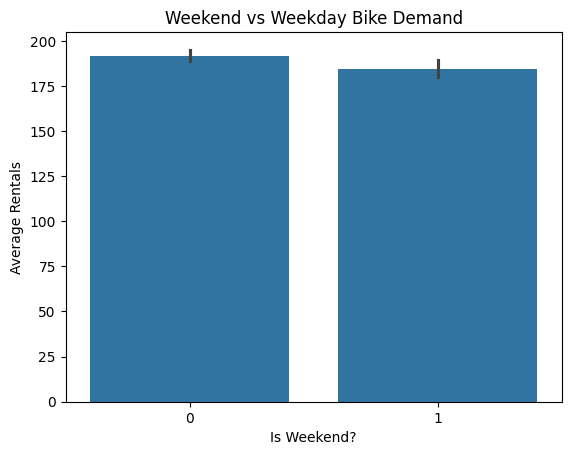

In [27]:
sns.barplot(x='is_weekend', y='cnt', data=df)
plt.title("Weekend vs Weekday Bike Demand")
plt.xlabel("Is Weekend?")
plt.ylabel("Average Rentals")
plt.show()


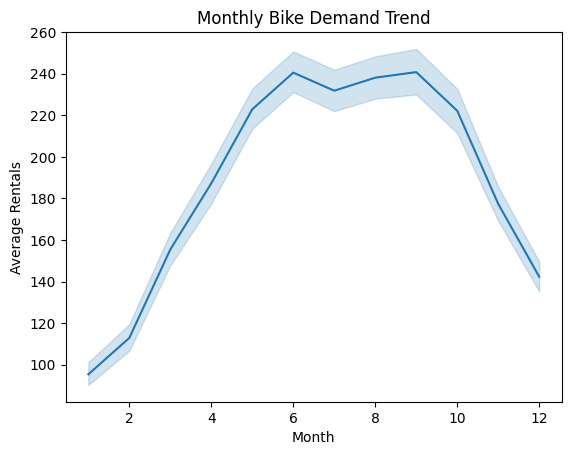

In [28]:
sns.lineplot(x="month", y="cnt", data=df)
plt.title("Monthly Bike Demand Trend")
plt.xlabel("Month")
plt.ylabel("Average Rentals")
plt.show()


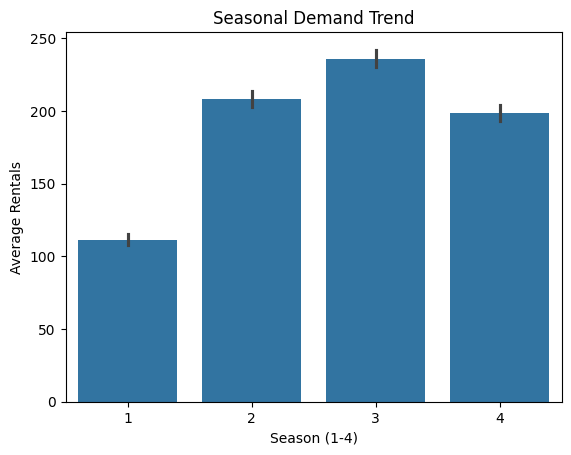

In [29]:
sns.barplot(x="season", y="cnt", data=df)
plt.title("Seasonal Demand Trend")
plt.xlabel("Season (1-4)")
plt.ylabel("Average Rentals")
plt.show()


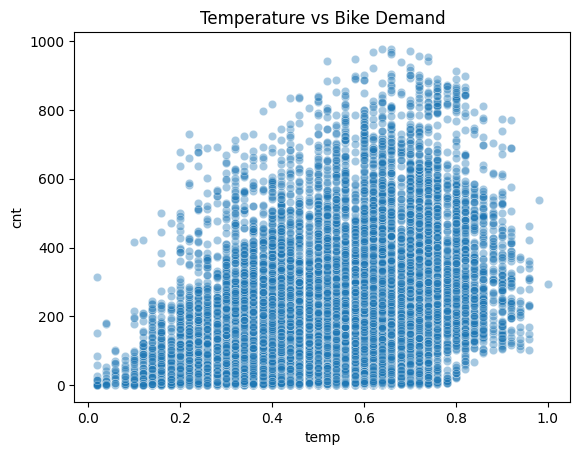

In [30]:
sns.scatterplot(x='temp', y='cnt', data=df, alpha=0.4)
plt.title("Temperature vs Bike Demand")
plt.show()


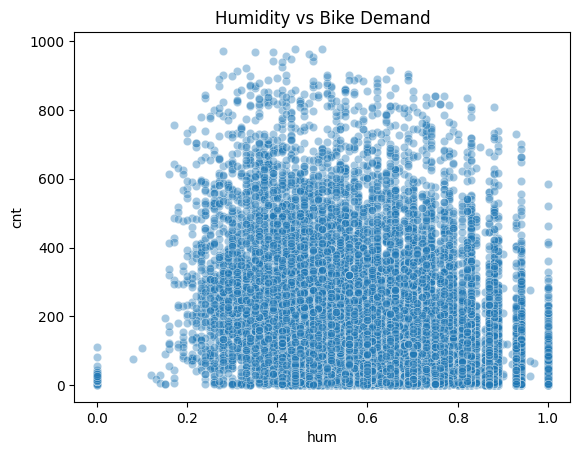

In [31]:
sns.scatterplot(x='hum', y='cnt', data=df, alpha=0.4)
plt.title("Humidity vs Bike Demand")
plt.show()


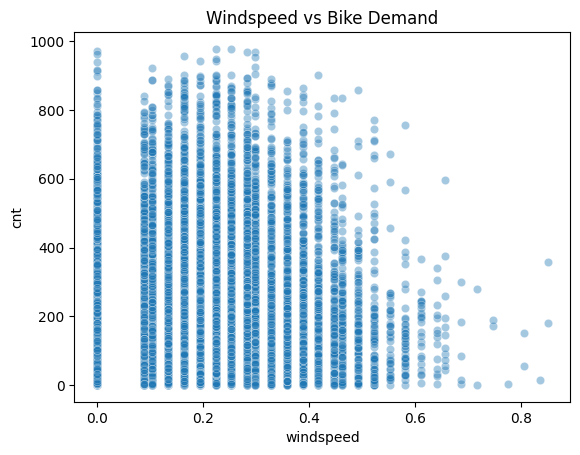

In [32]:
sns.scatterplot(x='windspeed', y='cnt', data=df, alpha=0.4)
plt.title("Windspeed vs Bike Demand")
plt.show()


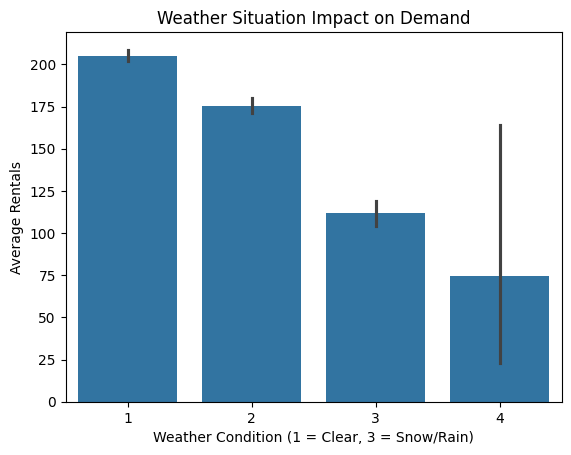

In [33]:
sns.barplot(x="weathersit", y="cnt", data=df)
plt.title("Weather Situation Impact on Demand")
plt.xlabel("Weather Condition (1 = Clear, 3 = Snow/Rain)")
plt.ylabel("Average Rentals")
plt.show()


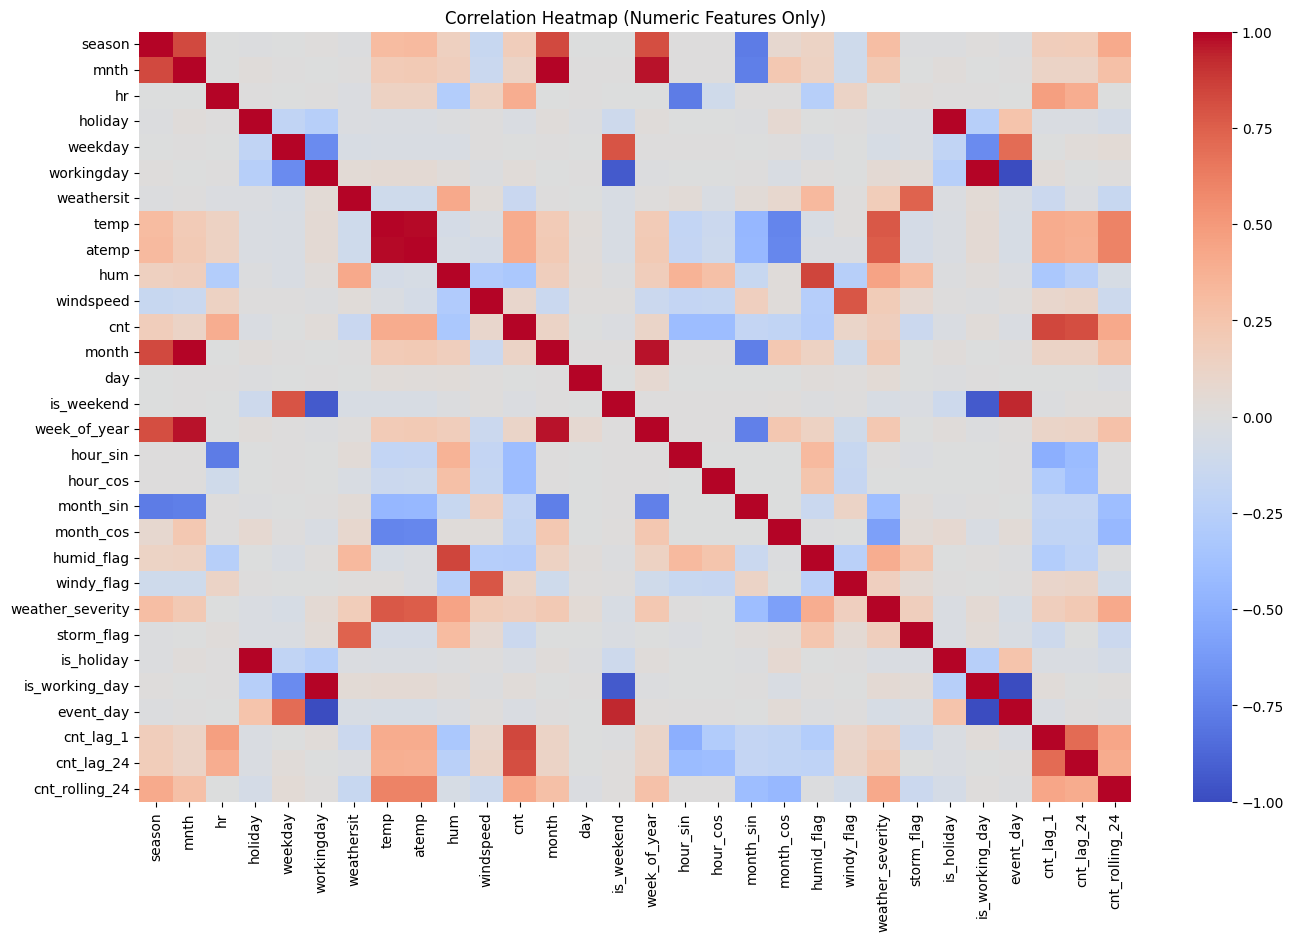

In [34]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(16, 10))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()


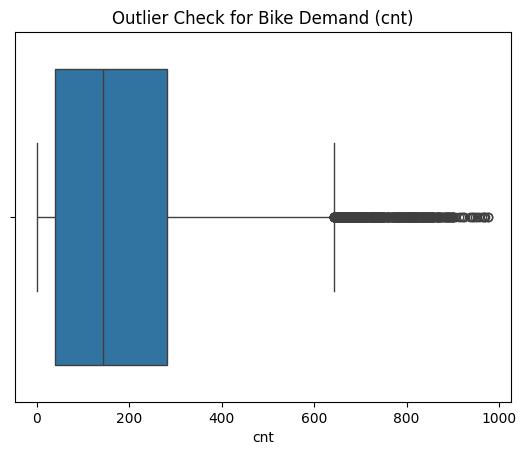

In [35]:
sns.boxplot(x=df['cnt'])
plt.title("Outlier Check for Bike Demand (cnt)")
plt.show()


In [39]:
# List of columns to remove (duplicates + unnecessary)
columns_to_remove = [

    "month",        # duplicate of mnth
    "day",          # not useful for hourly analysis
    "temp_level",   # categorical version of temp
    "humid_flag",   # duplicate of hum
    "windy_flag",   # duplicate of windspeed

    # Duplicate event features
    "is_holiday",       # same as holiday
    "is_working_day",   # same as workingday

]

columns_to_remove = [col for col in columns_to_remove if col in df.columns]

df.drop(columns_to_remove, axis=1, inplace=True)

print("Removed columns:", columns_to_remove)
print("\nRemaining columns:", df.columns.tolist())


Removed columns: ['month', 'day', 'temp_level', 'humid_flag', 'windy_flag', 'is_holiday', 'is_working_day']

Remaining columns: ['season', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt', 'is_weekend', 'week_of_year', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'weather_severity', 'storm_flag', 'event_day', 'cnt_lag_1', 'cnt_lag_24', 'cnt_rolling_24']


# Finding outliers


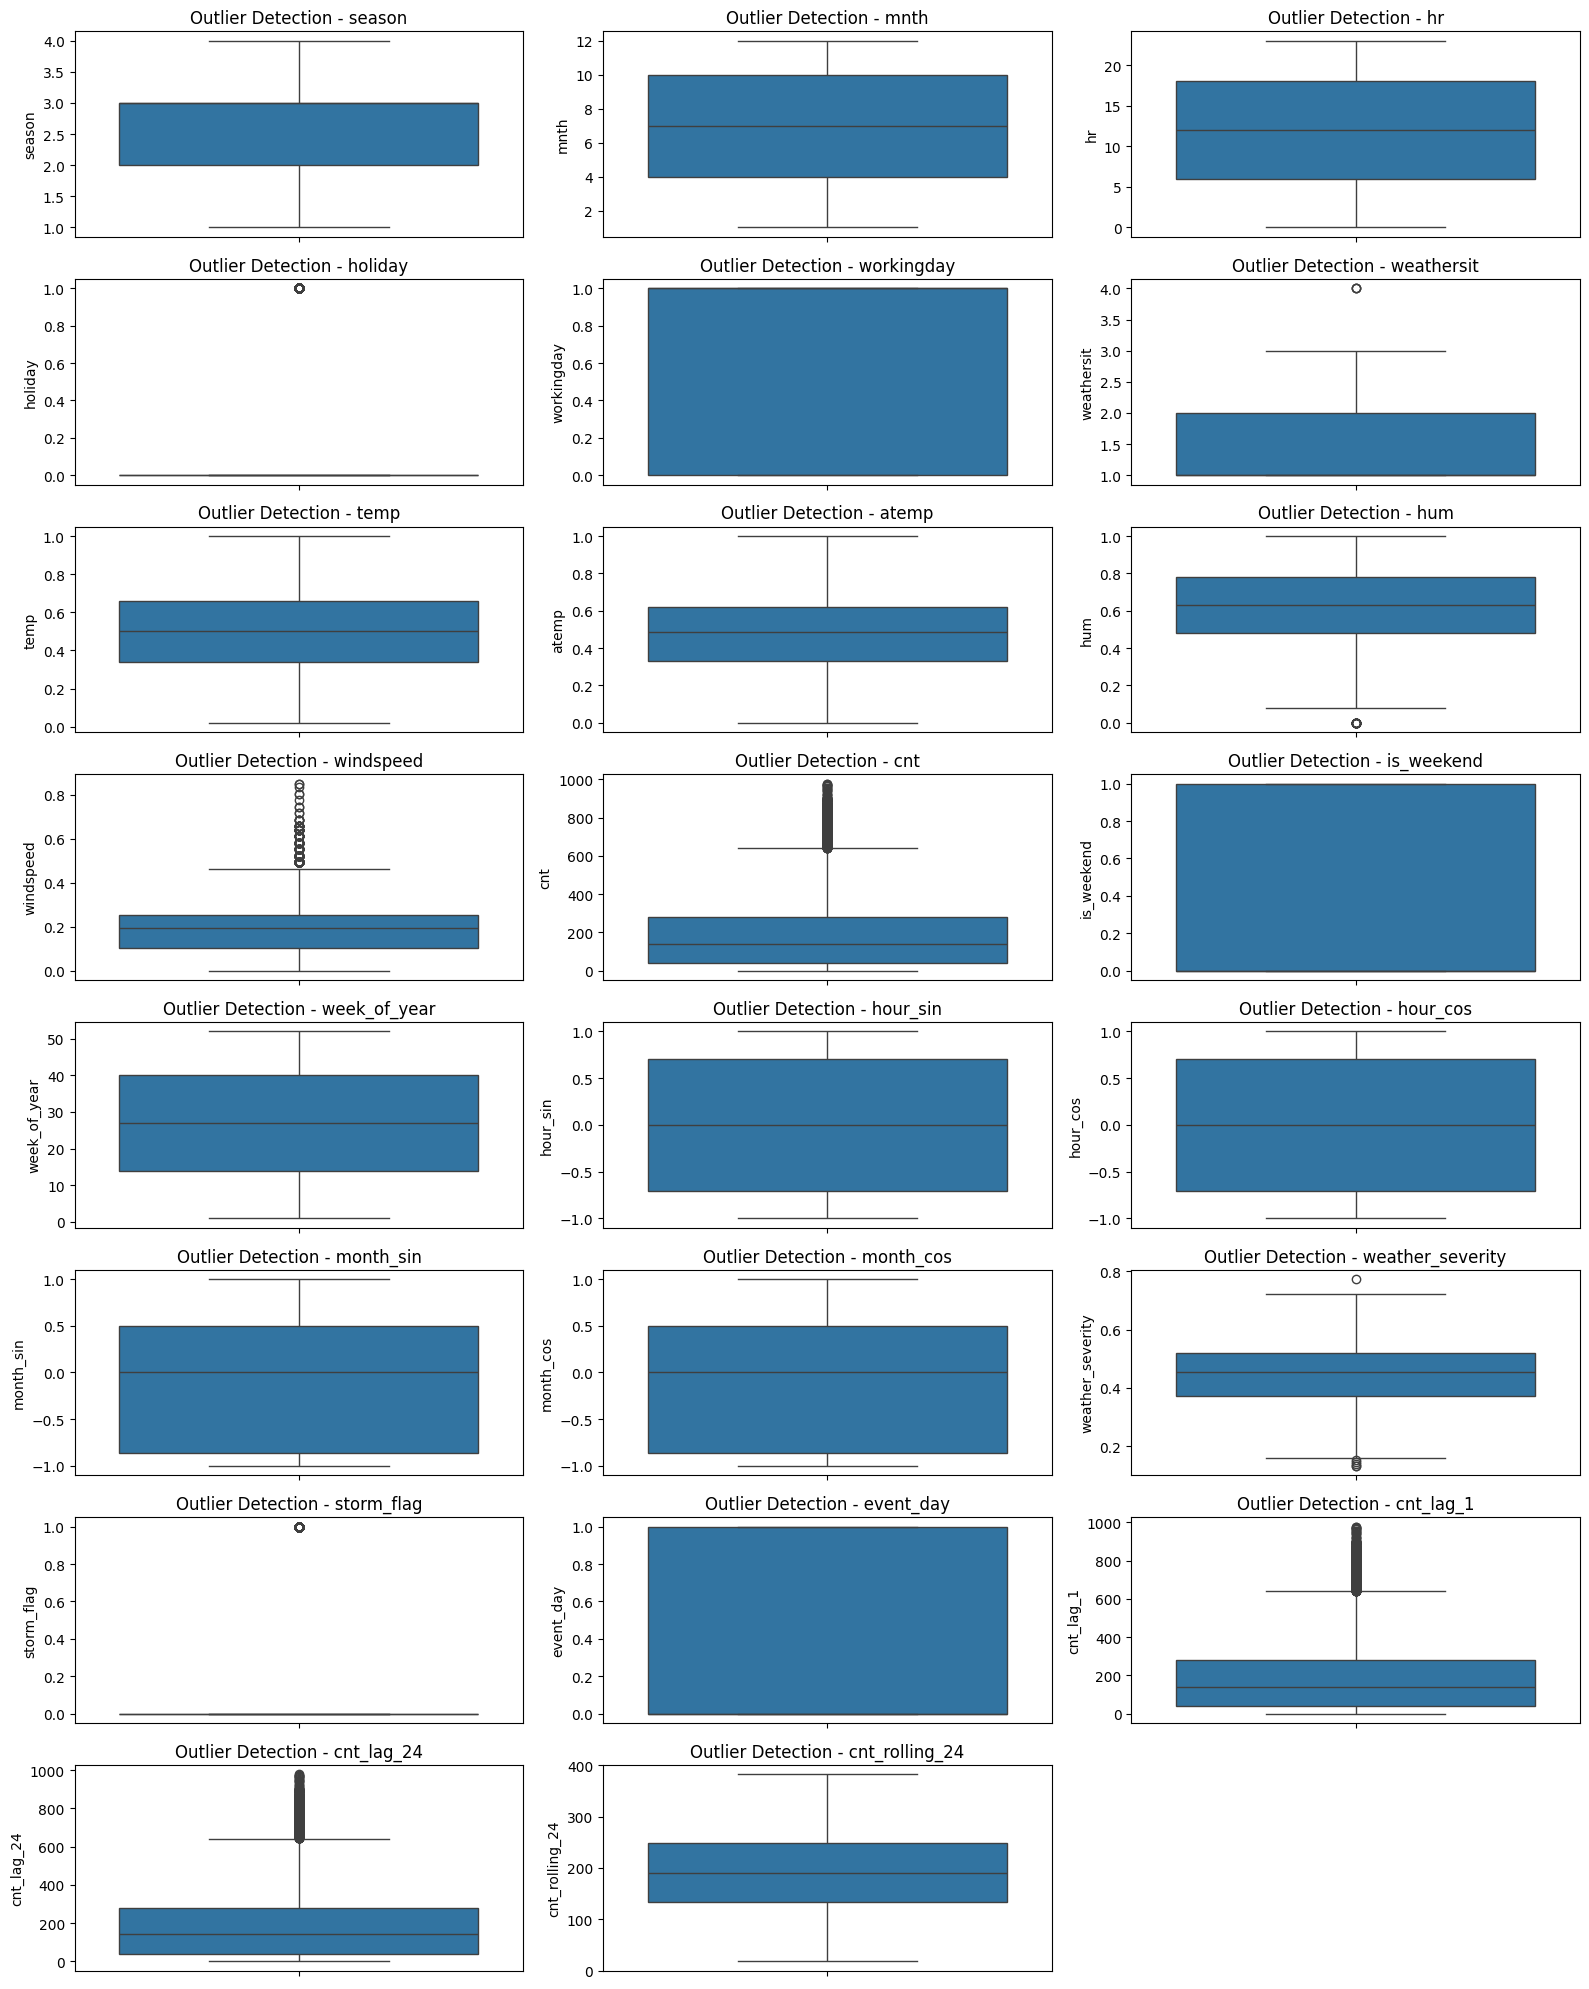

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(16, 20))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols)//3 + 1, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f"Outlier Detection - {col}")

plt.tight_layout()
plt.show()


In [41]:
import numpy as np

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("===== OUTLIER COUNTS (IQR METHOD) =====")

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    print(f"{col}: {outliers.count()} outliers")


===== OUTLIER COUNTS (IQR METHOD) =====
season: 0 outliers
mnth: 0 outliers
hr: 0 outliers
holiday: 500 outliers
workingday: 0 outliers
weathersit: 3 outliers
temp: 0 outliers
atemp: 0 outliers
hum: 22 outliers
windspeed: 342 outliers
cnt: 505 outliers
is_weekend: 0 outliers
week_of_year: 0 outliers
hour_sin: 0 outliers
hour_cos: 0 outliers
month_sin: 0 outliers
month_cos: 0 outliers
weather_severity: 6 outliers
storm_flag: 1420 outliers
event_day: 0 outliers
cnt_lag_1: 505 outliers
cnt_lag_24: 505 outliers
cnt_rolling_24: 0 outliers


removing outliers

In [42]:
import numpy as np

# Make a copy of dataset (optional but safe)
df_clean = df.copy()

numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

print("===== Removing Outliers Using IQR =====")

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    before = df_clean.shape[0]

    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

    after = df_clean.shape[0]

    print(f"{col}: Removed {before - after} outliers")

print("\nFinal Dataset Shape After Outlier Removal:", df_clean.shape)


===== Removing Outliers Using IQR =====
season: Removed 0 outliers
mnth: Removed 0 outliers
hr: Removed 0 outliers
holiday: Removed 500 outliers
workingday: Removed 0 outliers
weathersit: Removed 3 outliers
temp: Removed 0 outliers
atemp: Removed 0 outliers
hum: Removed 22 outliers
windspeed: Removed 333 outliers
cnt: Removed 470 outliers
is_weekend: Removed 0 outliers
week_of_year: Removed 0 outliers
hour_sin: Removed 0 outliers
hour_cos: Removed 0 outliers
month_sin: Removed 0 outliers
month_cos: Removed 0 outliers
weather_severity: Removed 4 outliers
storm_flag: Removed 1314 outliers
event_day: Removed 0 outliers
cnt_lag_1: Removed 351 outliers
cnt_lag_24: Removed 258 outliers
cnt_rolling_24: Removed 0 outliers

Final Dataset Shape After Outlier Removal: (14100, 24)


# Model training Linear reg

In [43]:
# Columns for modeling
model_cols = [
    "season", "mnth", "hr", "weekday", "is_weekend", "week_of_year",
    "temp", "atemp", "hum", "windspeed", "weathersit",
    "weather_severity", "storm_flag",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "cnt_lag_1", "cnt_lag_24",
    "cnt"
]

# Keep only columns that actually exist in the cleaned dataframe
model_cols = [col for col in model_cols if col in df_clean.columns]

# Create model dataset
model_df = df_clean[model_cols]

print("Final model dataset shape:", model_df.shape)
model_df.head()


Final model dataset shape: (14100, 20)


,season,mnth,hr,weekday,is_weekend,week_of_year,temp,atemp,hum,windspeed,weathersit,weather_severity,storm_flag,hour_sin,hour_cos,month_sin,month_cos,cnt_lag_1,cnt_lag_24,cnt
0,1,1,0,6,1,52,0.46,0.4545,0.88,0.2985,2,0.53755,0,0.000000,1.000000,0.5,0.866025,39.0,16.0,17
1,1,1,1,6,1,52,0.44,0.4394,0.94,0.2537,2,0.53411,0,0.258819,0.965926,0.5,0.866025,17.0,40.0,17
2,1,1,2,6,1,52,0.42,0.4242,1.00,0.2836,2,0.55308,0,0.500000,0.866025,0.5,0.866025,17.0,32.0,9
3,1,1,3,6,1,52,0.46,0.4545,0.94,0.1940,2,0.52420,0,0.707107,0.707107,0.5,0.866025,9.0,13.0,6
4,1,1,4,6,1,52,0.46,0.4545,0.94,0.1940,2,0.52420,0,0.866025,0.500000,0.5,0.866025,6.0,1.0,3


In [44]:
from sklearn.model_selection import train_test_split

X = model_df.drop("cnt", axis=1)
y = model_df["cnt"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (11280, 19)
Test shape: (2820, 19)


In [45]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

print("Model Trained: Linear Regression")


Model Trained: Linear Regression


In [46]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = lr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)


RMSE: 64.50563665275185
R² Score: 0.8039798294011199


In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


# Desion tree

In [48]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("===== Decision Tree Regressor =====")
print("RMSE:", rmse_dt)
print("R² Score:", r2_dt)


===== Decision Tree Regressor =====
RMSE: 41.17619983223456
R² Score: 0.9201273751688364


[Text(0.5095167389186063, 0.9861111111111112, 'x[17] <= 159.5\nsquared_error = 21710.114\nsamples = 11280\nvalue = 168.342'),
 Text(0.22127404377528628, 0.9583333333333334, 'x[14] <= -0.0\nsquared_error = 6339.553\nsamples = 6225\nvalue = 73.295'),
 Text(0.36539539134694626, 0.9722222222222223, 'True  '),
 Text(0.06771941116543609, 0.9305555555555556, 'x[17] <= 85.5\nsquared_error = 8668.601\nsamples = 1895\nvalue = 149.298'),
 Text(0.03135177247642459, 0.9027777777777778, 'x[17] <= 34.5\nsquared_error = 2663.589\nsamples = 782\nvalue = 85.909'),
 Text(0.011194941418448104, 0.875, 'x[17] <= 15.5\nsquared_error = 708.457\nsamples = 269\nvalue = 47.372'),
 Text(0.0058532872161971535, 0.8472222222222222, 'x[17] <= 9.5\nsquared_error = 208.997\nsamples = 104\nvalue = 24.942'),
 Text(0.003913129392895211, 0.8194444444444444, 'x[6] <= 0.53\nsquared_error = 121.138\nsamples = 61\nvalue = 17.672'),
 Text(0.0027952984752786284, 0.7916666666666666, 'x[17] <= 4.5\nsquared_error = 81.301\nsamples 

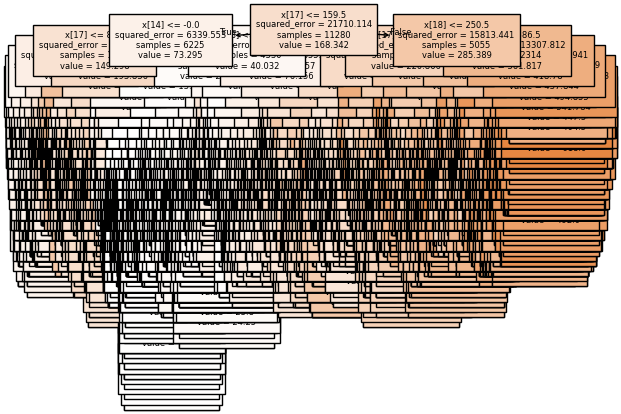

In [49]:
from sklearn import tree
tree.plot_tree(dt, filled=True, fontsize=6)


# Random forest

In [50]:
# Select final feature columns for Random Forest training
model_cols = [
    "season", "mnth", "hr", "weekday", "is_weekend", "week_of_year",
    "temp", "atemp", "hum", "windspeed", "weathersit",
    "weather_severity", "storm_flag",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "cnt_lag_1", "cnt_lag_24",
    "cnt"
]

model_cols = [col for col in model_cols if col in df_clean.columns]

# Final dataset
model_df = df_clean[model_cols]

# Split into features and label
X = model_df.drop("cnt", axis=1)
y = model_df["cnt"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


Train Shape: (11280, 19)
Test Shape: (2820, 19)


In [51]:
from sklearn.ensemble import RandomForestRegressor

# Create model
rf = RandomForestRegressor(
    n_estimators=200,       # number of trees
    max_depth=None,         # let trees grow fully
    random_state=42,
    n_jobs=-1               # faster training
)

# Train the model
rf.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")


Random Forest Model Trained Successfully!


In [52]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Predictions
y_pred_rf = rf.predict(X_test)

# Metrics
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("===== Random Forest Evaluation =====")
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)


===== Random Forest Evaluation =====
RMSE: 29.01994782833387
R² Score: 0.9603266671803915


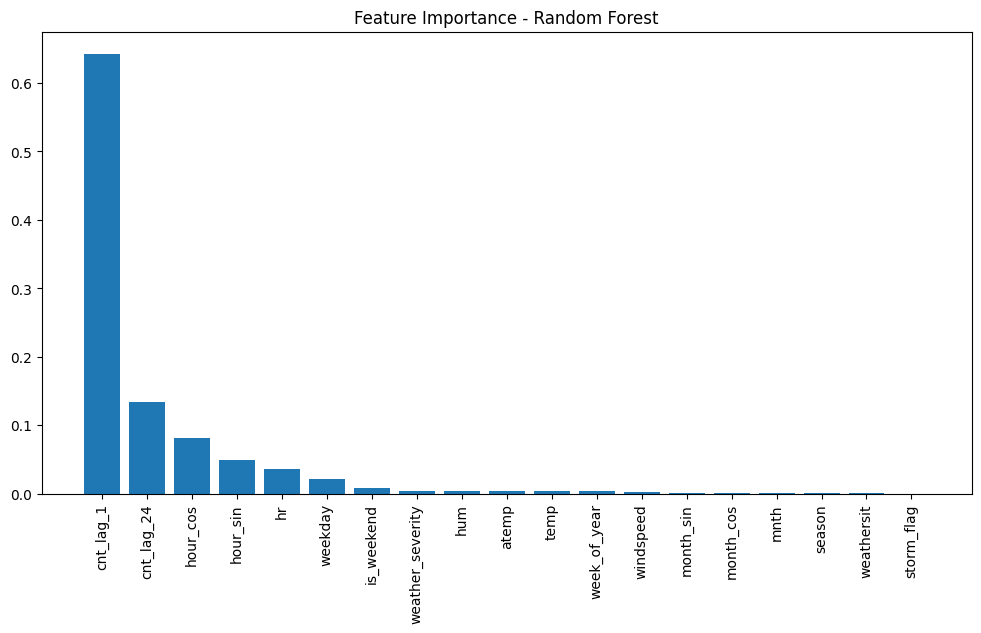

In [53]:
import matplotlib.pyplot as plt
import numpy as np

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12,6))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), X.columns[indices], rotation=90)
plt.title("Feature Importance - Random Forest")
plt.show()


# Gradent

In [54]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Create model
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

# Train
gbr.fit(X_train, y_train)

print("Gradient Boosting Model Trained Successfully!")


Gradient Boosting Model Trained Successfully!


In [55]:
# Predictions
y_pred_gbr = gbr.predict(X_test)

# Metrics
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

print("===== Gradient Boosting Evaluation =====")
print("RMSE:", rmse_gbr)
print("R² Score:", r2_gbr)


===== Gradient Boosting Evaluation =====
RMSE: 28.681775947397156
R² Score: 0.9612459131013663


# XGboost

In [56]:
!pip install xgboost


In [57]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Create XGBoost model
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

# Train model
xgb.fit(X_train, y_train)

print("XGBoost Model Trained Successfully!")


XGBoost Model Trained Successfully!


In [58]:
# Predict
y_pred_xgb = xgb.predict(X_test)

# Metrics
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("===== XGBoost Evaluation =====")
print("RMSE:", rmse_xgb)
print("R² Score:", r2_xgb)


===== XGBoost Evaluation =====
RMSE: 27.169596071410297
R² Score: 0.9652246236801147


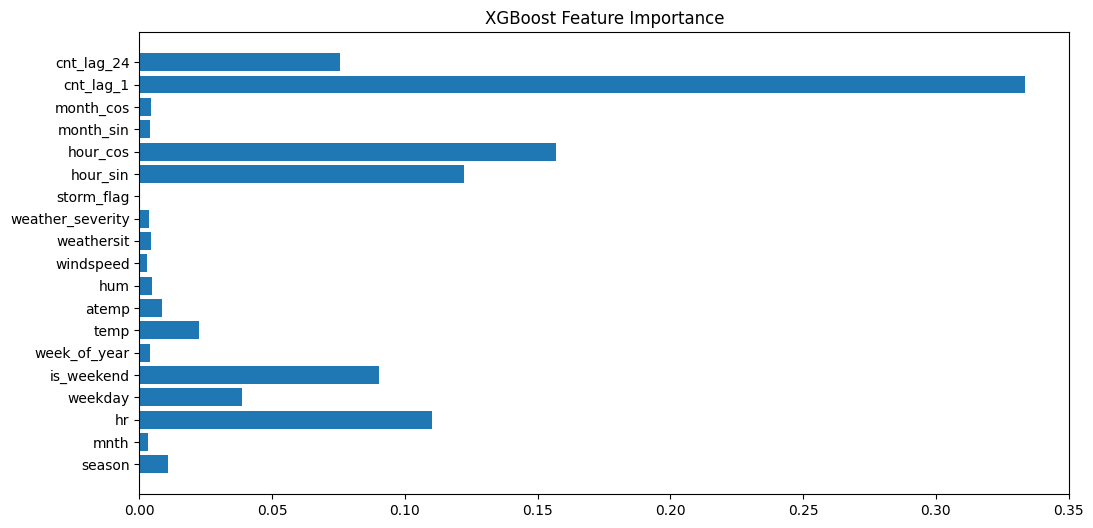

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.barh(X.columns, xgb.feature_importances_)
plt.title("XGBoost Feature Importance")
plt.show()


# LightGBM

In [60]:
!pip install lightgbm


In [61]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Create LightGBM model
lgbm = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train the model
lgbm.fit(X_train, y_train)

print("LightGBM Model Trained Successfully!")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001793 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1143
[LightGBM] [Info] Number of data points in the train set: 11280, number of used features: 18
[LightGBM] [Info] Start training from score 168.342110
LightGBM Model Trained Successfully!


In [62]:
# Predict
y_pred_lgbm = lgbm.predict(X_test)

# Metrics
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
r2_lgbm = r2_score(y_test, y_pred_lgbm)

print("===== LightGBM Evaluation =====")
print("RMSE:", rmse_lgbm)
print("R² Score:", r2_lgbm)


===== LightGBM Evaluation =====
RMSE: 27.270168368647095
R² Score: 0.9649666982671345


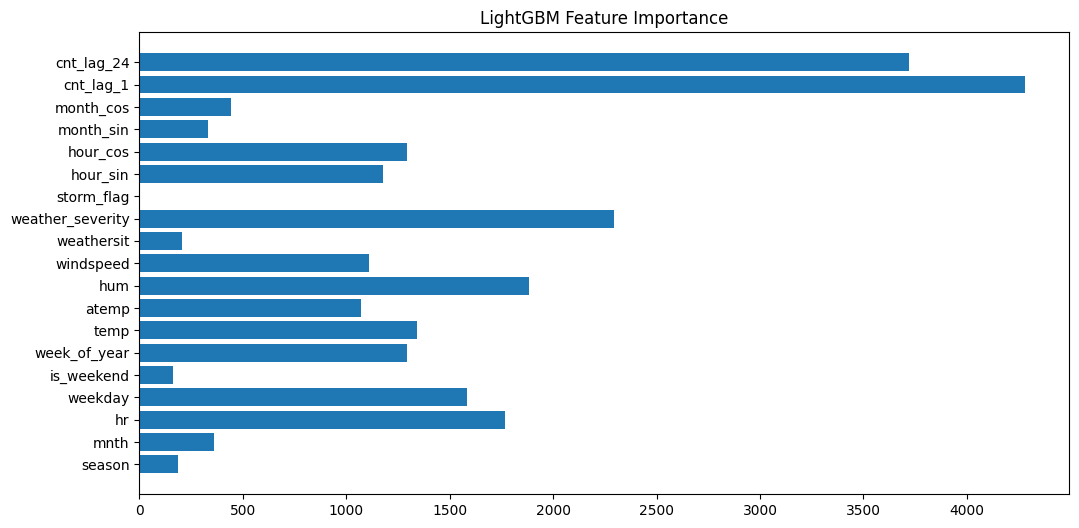

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.barh(X.columns, lgbm.feature_importances_)
plt.title("LightGBM Feature Importance")
plt.show()


# comparing models

In [65]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

models = {
    "Linear Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gbr,
    "XGBoost": xgb,
    "LightGBM": lgbm
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R² Score"])
print("\n===== MODEL COMPARISON TABLE =====\n")
print(results_df)



===== MODEL COMPARISON TABLE =====

               Model        MAE       RMSE  R² Score
0  Linear Regression  42.037759  64.505637  0.803980
1      Decision Tree  27.249645  41.176200  0.920127
2      Random Forest  18.850619  29.019948  0.960327
3  Gradient Boosting  18.846085  28.681776  0.961246
4            XGBoost  17.984322  27.169596  0.965225
5           LightGBM  18.099549  27.270168  0.964967


In [66]:
# best model = model with highest R² Score
best_model_name = results_df.sort_values(by="R² Score", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

print("\n===== BEST MODEL SELECTED =====")
print("Best Model:", best_model_name)



===== BEST MODEL SELECTED =====
Best Model: XGBoost


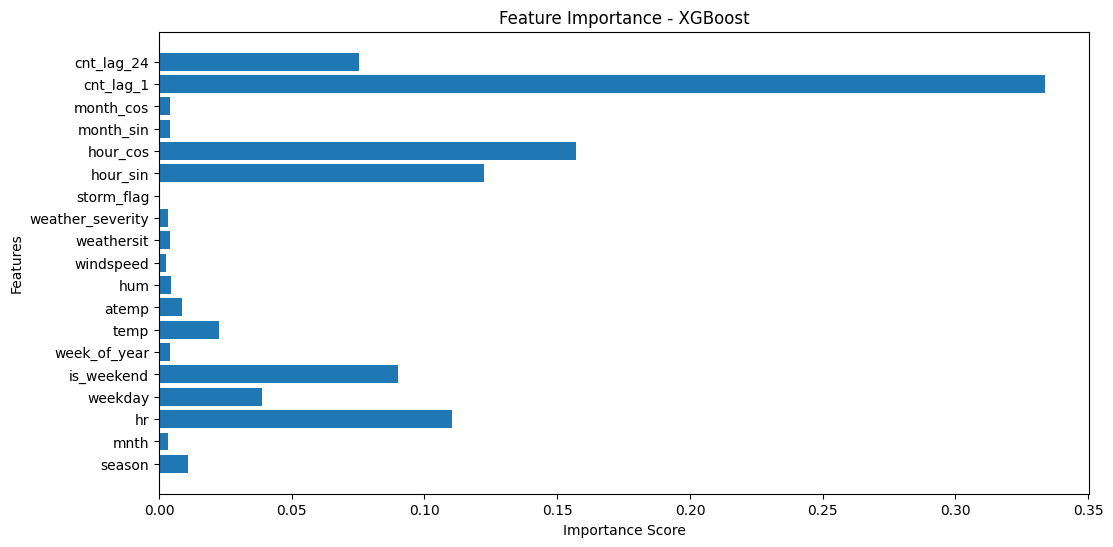

In [67]:
import matplotlib.pyplot as plt

# Models that support feature importances
tree_models = ["Decision Tree", "Random Forest", "Gradient Boosting", "XGBoost", "LightGBM"]

if best_model_name in tree_models:
    importances = best_model.feature_importances_

    plt.figure(figsize=(12, 6))
    plt.barh(X.columns, importances)
    plt.title(f"Feature Importance - {best_model_name}")
    plt.xlabel("Importance Score")
    plt.ylabel("Features")
    plt.show()
else:
    print("Feature importance not available for this model.")


In [68]:
y_pred_best = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_best)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2 = r2_score(y_test, y_pred_best)

print("\n===== BEST MODEL PREDICTION RESULTS =====")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)



===== BEST MODEL PREDICTION RESULTS =====
MAE: 17.98432159423828
RMSE: 27.169596071410297
R² Score: 0.9652246236801147


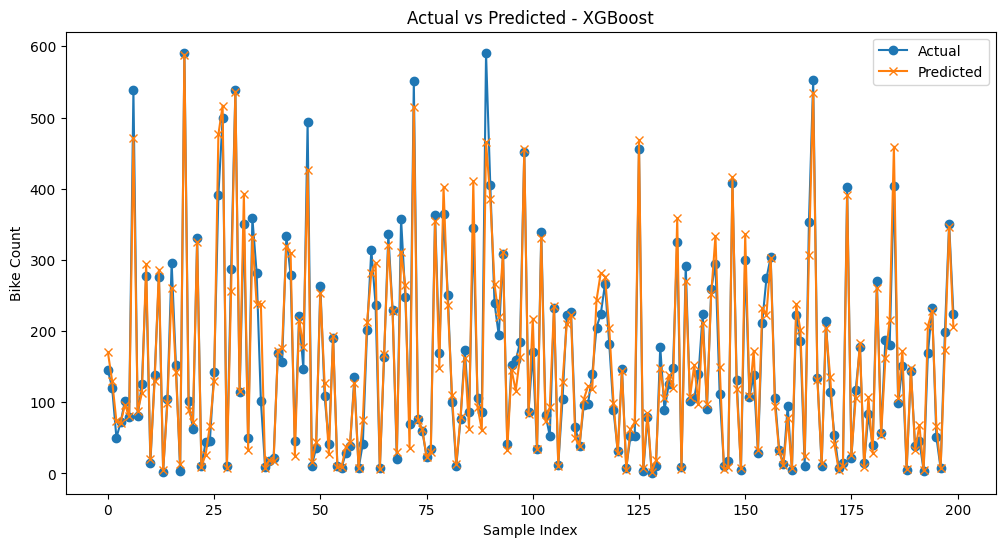

In [69]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values[:200], label="Actual", marker='o')
plt.plot(y_pred_best[:200], label="Predicted", marker='x')
plt.title(f"Actual vs Predicted - {best_model_name}")
plt.xlabel("Sample Index")
plt.ylabel("Bike Count")
plt.legend()
plt.show()


In [70]:
from sklearn.model_selection import RandomizedSearchCV

if best_model_name == "Random Forest":
    param_grid = {
        'n_estimators': [200, 400, 600],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'bootstrap': [True, False]
    }
    model_base = rf

elif best_model_name == "XGBoost":
    param_grid = {
        'n_estimators': [300, 500, 800],
        'learning_rate': [0.01, 0.03, 0.05],
        'max_depth': [5, 7, 10],
        'subsample': [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0]
    }
    model_base = xgb

elif best_model_name == "LightGBM":
    param_grid = {
        'num_leaves': [31, 50, 70],
        'learning_rate': [0.01, 0.03, 0.05],
        'n_estimators': [300, 500, 800],
        'max_depth': [-1, 10, 20],
        'subsample': [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0]
    }
    model_base = lgbm

else:
    print("Fine-tuning not supported for this model.")
    model_base = None

if model_base is not None:
    tuner = RandomizedSearchCV(
        estimator=model_base,
        param_distributions=param_grid,
        n_iter=15,
        scoring='neg_mean_squared_error',
        cv=3,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    tuner.fit(X_train, y_train)

    best_model_tuned = tuner.best_estimator_

    print("\n===== BEST TUNED PARAMETERS =====")
    print(tuner.best_params_)


Fitting 3 folds for each of 15 candidates, totalling 45 fits

===== BEST TUNED PARAMETERS =====
{'subsample': 1.0, 'n_estimators': 800, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [71]:
y_pred_tuned = best_model_tuned.predict(X_test)

mae_t = mean_absolute_error(y_test, y_pred_tuned)
rmse_t = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_t = r2_score(y_test, y_pred_tuned)

print("\n===== TUNED MODEL RESULTS =====")
print("MAE:", mae_t)
print("RMSE:", rmse_t)
print("R² Score:", r2_t)



===== TUNED MODEL RESULTS =====
MAE: 18.03458023071289
RMSE: 27.37403791295972
R² Score: 0.9646993279457092
